In [58]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D, Conv1D, MaxPooling1D, Embedding, Dropout,  BatchNormalization
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt

# Para esta pratica de NLP obtive um bom resultado com 89% de acuracia

In [2]:
!wget https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv -O ag_news_train.csv
!wget https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv -O ag_news_test.csv
# baixa o dataset de noticias o intuito é classificar a qual classe pertence a noticia(problema de multiclasse)

--2026-08-13 10:54:23--  https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv
Resolvendo raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8001::154, 2606:50c0:8002::154, 2606:50c0:8003::154, ...
Conectando-se a raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8001::154|:443... conectado.
A requisição HTTP foi enviada, aguardando resposta... 200 OK
Tamanho: 29470338 (28M) [text/plain]
Salvando em: ‘ag_news_train.csv’

ag_news_train.csv   100%[===================>]  28,10M  6,86MB/s    em 4,5s    

2026-08-13 10:54:28 (6,24 MB/s) - ‘ag_news_train.csv’ salvo [29470338/29470338]

--2026-08-13 10:54:28--  https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv
Resolvendo raw.githubusercontent.com (raw.githubusercontent.com)... 2606:50c0:8002::154, 2606:50c0:8001::154, 2606:50c0:8003::154, ...
Conectando-se a raw.githubusercontent.com (raw.githubusercontent.com)|2606:50c0:8002::154|:443

In [3]:
df = pd.read_csv('/home/beuren/Documentos/LAMIA-Bootcamp/card-17/pratice/ag_news_train.csv')

In [4]:
df.head()
# o dataset veio sem o nome das colunas vou reimportar

,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again."
0,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
1,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
2,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
3,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."
4,3,"Stocks End Up, But Near Year Lows (Reuters)",Reuters - Stocks ended slightly higher on Frid...


In [5]:
cols = ['label', 'Title', 'Description']
# nomes para as colunas
df_train = pd.read_csv('/home/beuren/Documentos/LAMIA-Bootcamp/card-17/pratice/ag_news_train.csv', names=cols)
df_test = pd.read_csv('/home/beuren/Documentos/LAMIA-Bootcamp/card-17/pratice/ag_news_test.csv', names=cols)

In [6]:
df_train.head()

,label,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [7]:
df_train.isnull().sum()
#verifica se tem NaN

label          0
Title          0
Description    0
dtype: int64

In [8]:
df_test.isnull().sum()

label          0
Title          0
Description    0
dtype: int64

In [9]:
df_train['label'] = df_train['label'] -1
# mudao intevalo das classes em 0 a 3

In [10]:
df_test['label'] = df_test['label'] -1

In [11]:
df_train.shape

(120000, 3)

In [12]:
df_test.shape

(7600, 3)

In [13]:
df = pd.concat([df_train,df_test])
df.shape

(127600, 3)

In [14]:
df_x, df_y = df['Description'].values , df['label'].values

In [15]:
x_train, x_test, y_train, y_test = train_test_split(df_x,df_y, test_size=0.3)

In [16]:
VOCAB_LIMIT = 50000
tk = Tokenizer(num_words=VOCAB_LIMIT)#crio o objeto tokenizador com o limite de palavras
tk.fit_on_texts(x_train)# separa por tokens

In [17]:
train_seq = tk.texts_to_sequences(x_train)# coloca os tokens em uma seuqencia de inteiros
test_seq = tk.texts_to_sequences(x_test)

In [18]:
pala = tk.word_index # pega todas as palavras e indices
print(pala)
V= len(pala) # pega a quantidade de indices
print(V)

{'the': 1, 'a': 2, 'to': 3, 'of': 4, 'in': 5, 'and': 6, 'on': 7, 'for': 8, '39': 9, 's': 10, 'that': 11, 'with': 12, 'as': 13, 'its': 14, 'at': 15, 'said': 16, 'is': 17, 'by': 18, 'it': 19, 'has': 20, 'new': 21, 'an': 22, 'from': 23, 'reuters': 24, 'his': 25, 'was': 26, 'will': 27, 'after': 28, 'have': 29, 'be': 30, 'their': 31, 'two': 32, 'are': 33, 'us': 34, 'over': 35, 'quot': 36, 'first': 37, 'year': 38, 'ap': 39, 'he': 40, 'but': 41, 'gt': 42, 'lt': 43, 'this': 44, 'more': 45, 'monday': 46, 'tuesday': 47, 'wednesday': 48, 'one': 49, 'up': 50, 'thursday': 51, 'company': 52, 'inc': 53, 'friday': 54, 'world': 55, 'than': 56, 'u': 57, '1': 58, 'last': 59, 'they': 60, 'york': 61, 'yesterday': 62, 'against': 63, 'about': 64, 'who': 65, 'not': 66, 'were': 67, 'into': 68, 'out': 69, 'been': 70, 'three': 71, '2': 72, 'president': 73, 'had': 74, 'million': 75, 'corp': 76, 'oil': 77, 'week': 78, 'when': 79, 'time': 80, 'sunday': 81, 'which': 82, 'would': 83, 'united': 84, 'game': 85, 'people

In [19]:
dt_train = pad_sequences(sequences=train_seq) # coloca 0s em sequencias para ficarem no mesmo tamanho
T=dt_train.shape[1]# quantidade de colunas(indices totais)
print(dt_train.shape)


(89320, 173)


In [20]:
dt_test = pad_sequences(sequences=test_seq, maxlen=T) # o maxlen permite que aloque 0 ate o mesmo tamano do treino
print(dt_test.shape)

(38280, 173)


In [21]:
D = 30 # numero de dimensoes, parametro testavel

In [22]:
K =len(set(df_y))

In [23]:
K

4

In [64]:
i = Input(shape=(T,))# quantidade de neuronios que a rede precisa
x= Embedding(V+1,D)(i) # cria uma matriz de vetores densos para cada token. Nesse caso a matriz 57169x173
x=Conv1D(32,2,activation='relu')(x)# aplicaçaõ de feature maps atraves do operador de convolucao
x = BatchNormalization()(x)
x=MaxPooling1D(2)(x)# diminui o tamanho pela metade

x=Conv1D(64,2,activation='relu')(x)
x = BatchNormalization()(x)
x=MaxPooling1D(2)(x)

#x=Conv1D(128,4,activation='relu')(x)    
#x=MaxPooling1D(2)(x)
#x=Conv1D(256,4,activation='relu')(x)

x=GlobalMaxPooling1D()(x) # vetoriza tudo
x = Dropout(0.5)(x)
x=Dense(64,activation='relu')(x)# camada densa de neuronios

x = Dropout(0.5)(x)
x=Dense(K,activation='softmax')(x)# camada de saida

model = Model(i,x)

In [65]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# define otimizador de pesos e metricas 

In [66]:
result = model.fit(dt_train,y_train, epochs= 5,validation_data=(dt_test,y_test))
# treina o modelo, e depois valida com dados que nunca viu

Epoch 1/5
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 55s 19ms/step - accuracy: 0.2756 - loss: 1.4807 - val_accuracy: 0.5393 - val_loss: 1.1418
Epoch 2/5
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 56s 20ms/step - accuracy: 0.7144 - loss: 0.7281 - val_accuracy: 0.8644 - val_loss: 0.4226
Epoch 3/5
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 58s 21ms/step - accuracy: 0.8789 - loss: 0.3921 - val_accuracy: 0.8854 - val_loss: 0.3385
Epoch 4/5
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 58s 21ms/step - accuracy: 0.9049 - loss: 0.3035 - val_accuracy: 0.8898 - val_loss: 0.3249
Epoch 5/5
2792/2792 ━━━━━━━━━━━━━━━━━━━━ 59s 21ms/step - accuracy: 0.9225 - loss: 0.2440 - val_accuracy: 0.8939 - val_loss: 0.3250


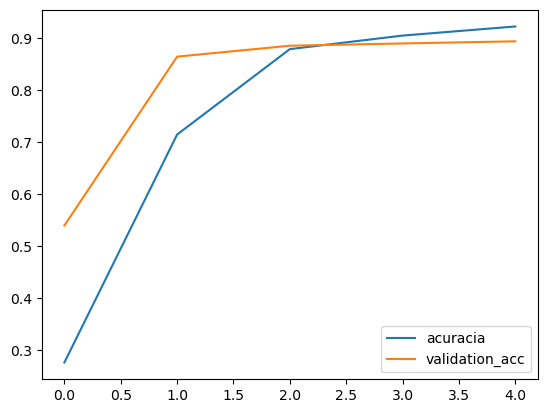

In [67]:
# grafico que mede a acuracia durante o treino e com dados que nunca viu
plt.plot(result.history['accuracy'],label='acuracia')
plt.plot(result.history['val_accuracy'],label='validation_acc')
plt.legend()

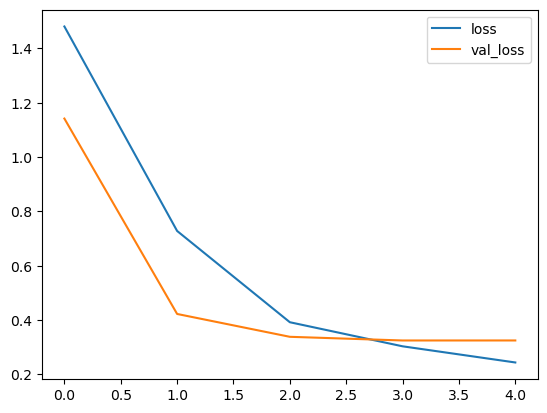

In [68]:
# grafico que mede o loss durante o treino e com dados que nunca viu
plt.plot(result.history['loss'],label='loss')
plt.plot(result.history['val_loss'],label='val_loss')
plt.legend()